# EPCRC results — every claim, every number

This notebook is the results package. It displays exactly what the delivered
zip contains, because both call the same two modules:

- `epcrc/report.py` turns raw experiment JSON into tables
- `epcrc/figures.py` draws those tables

Nothing here recomputes an experiment. If a number is wrong, it is wrong in the
JSON and the experiment has to be rerun. That is deliberate: a notebook that
quietly recomputes its own version of a result is how a figure and a CSV end up
disagreeing.

The panel defaults to `"core8"` (smoke panel). Set the environment variable
`EPCRC_PANEL=core20` to run it against the formal panel.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

from epcrc import report as R
from epcrc import figures as F
from experiments.export_results import input_paths

# Set EPCRC_PANEL=core20 to execute this notebook against the formal panel,
# so a headless rerun does not need the file edited.
PANEL = os.environ.get("EPCRC_PANEL", "core8")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

PATHS = input_paths(PANEL)
print(f"panel: {PANEL}")
for key, path in PATHS.items():
    mark = "found  " if os.path.exists(path) else "MISSING"
    print(f"{mark}  {key:<14} {os.path.relpath(path, ROOT)}")

panel: core20
found    e0_synthetic   results/e0_noncomposability.json
found    e0_real        results/e0_real_core20.json
found    e1             results/e1_frontier_core20.json
found    c3             results/c3_baselines_core20.json
found    c4             results/c4_stress_specialists_core20.json


In [2]:
payload = R.load(PATHS["c3"])
block = payload["per_split_seed"][0]

print(f"judges            {len(block['judges'])}: {', '.join(block['judges'])}")
print(f"contexts          {len(block['contexts'])}: {', '.join(block['contexts'])}")
print(f"items per split   " + ", ".join(f"{k} {v}" for k, v in block["split_items"].items()))
print(f"split seeds       {payload['split_seeds']}")
print(f"bootstrap reps    {payload['n_bootstrap']}")
print()
print("Splits are grouped by source item, so no prompt appears in two splits.")
print("The pairs seed fixes what each judge saw and needs GPU time to change;")
print("the split seed only re-partitions the cached responses, which is free.")

judges            19: J01, J02, J03, J04, J05, J06, J08, J09, J10, J11, J12, J13, J14, J15, J16, J17, J18, J19, J20
contexts          7: I0_clean, I1_order_swap, I2_correctness_rubric, I3_bias_resistant_rubric, I4_verbosity_pad_a, I5_source_tags, I6_reference_hidden
items per split   FIT 1866, CERT 932, TEST 926
split seeds       [20260818, 20260819, 20260820, 20260821, 20260822]
bootstrap reps    2000

Splits are grouped by source item, so no prompt appears in two splits.
The pairs seed fixes what each judge saw and needs GPU time to change;
the split seed only re-partitions the cached responses, which is free.


---

## Claim C1 — individual redundancy certificates do not compose

> A judge certified removable on its own need not be removable alongside other
> judges that were each certified the same way.

**How it is tested.** For a tolerance $\gamma$, collect
$R(\gamma) = \{i : U(i \mid J \setminus \{i\}) \le \gamma\}$ — every judge
whose leave-one-out reconstruction error is within tolerance. Delete all of
$R(\gamma)$ at once and measure what the surviving panel achieves.

If certificates composed, the joint error would still be at most $\gamma$.

In [3]:
c1 = R.c1_table(PATHS["e0_real"])
loo = c1[["loo_min", "loo_median", "loo_max"]].agg(["min", "median", "max"])
print("leave-one-out error across judges and split seeds")
print(f"  min {c1['loo_min'].min():.4f}   median {c1['loo_median'].median():.4f}   max {c1['loo_max'].max():.4f}")

declared = R.c1_headline(PATHS["e0_real"], gamma_source="declared")
print()
print("predeclared gamma grid (plan section 23)")
display(declared)

leave-one-out error across judges and split seeds
  min 0.1308   median 0.3238   max 0.5509

predeclared gamma grid (plan section 23)


,instance,gamma,removable,naive_size,naive_coverage,min_feasible,min_feasible_exact,min_feasible_floor,composition_gap,cycles,seeds,naive_set_fails
0,core20_real,0.0200,0.0000,19.0000,0.0000,19.0000,False,6.0000,0.0000,1.0000,5,False
1,core20_real,0.0400,0.0000,19.0000,0.0000,19.0000,False,6.0000,0.0000,1.0000,5,False
2,core20_real,0.0600,0.0000,19.0000,0.0000,19.0000,False,6.0000,0.0000,1.0000,5,False
3,core20_real,0.0800,0.0000,19.0000,0.0000,19.0000,False,6.0000,0.0000,1.0000,5,False
4,core20_real,0.1000,0.0000,19.0000,0.0000,19.0000,False,6.0000,0.0000,1.0000,5,False
5,core20_real,0.1200,0.0000,19.0000,0.0000,19.0000,False,6.0000,0.0000,1.0000,5,False
6,core20_real,0.1500,1.0000,18.0000,0.1336,18.0000,False,6.0000,0.0000,1.0000,5,False
7,core20_real,0.2000,2.0000,17.0000,0.2115,18.0000,False,6.0000,1.0000,1.0000,5,True


Two tolerance grids appear below, and the distinction matters for how much the
result is worth.

**Predeclared** tolerances come from plan section 23 and were fixed before any
judge was scored. A violation there is the strongest form of C1 available: no
tolerance was chosen after seeing the data, and what is tested is one exact
coverage evaluation. It only says something when at least *two* judges clear
their own certificate at the same $\gamma$ — one removable judge is not a
composition test. On a smaller panel every leave-one-out error can sit above the
whole grid, leaving $R(\gamma)$ empty and the grid silent.

**Data-driven** tolerances are the leave-one-out errors themselves. $R(\gamma)$
only changes when $\gamma$ crosses one, so the sorted errors are the *complete*
set of informative tolerances — but they are read off the data, so they are
weaker evidence and are labelled as such everywhere they appear.

In [4]:
# The predeclared grid is read first because it is the stronger claim.  It is
# filtered to >= 2 individually removable judges: with one removable judge there
# is nothing to compose, so such a row is not evidence either way.
dec = c1[(c1["gamma_source"] == "declared") & (c1["n_individually_removable"] >= 2)]
if len(dec):
    g = dec["gamma"].min()
    at_g = dec[dec["gamma"] == g]
    print(f"PREDECLARED grid (plan section 23), tolerances fixed before scoring")
    print(f"  smallest gamma admitting >=2 removable judges : {g:g}")
    print(f"  judges each individually certified removable   : "
          f"{int(at_g['n_individually_removable'].mean())}")
    print(f"  joint deletion error                           : "
          f"{at_g['naive_coverage'].min():.4f}-{at_g['naive_coverage'].max():.4f}"
          f"  vs budget {g:g}")
    print(f"  split seeds in which that breaks the tolerance  : "
          f"{int(at_g['naive_violates_gamma'].sum())} of {len(at_g)}")
    print(f"  across the whole predeclared grid              : "
          f"{int(dec['naive_violates_gamma'].sum())} of {len(dec)} multi-removable cases fail")
else:
    print("PREDECLARED grid: no tolerance admits two removable judges, so the")
    print("grid cannot test composition on this panel. Reported, not worked around.")
print()

breaks = c1[(c1["gamma_source"] == "loo_breakpoint") & (c1["n_individually_removable"] >= 2)]

n_viol = int(breaks["naive_violates_gamma"].sum())
print("DATA-DRIVEN leave-one-out breakpoints (weaker evidence, larger n)")
print(f"  cases where >=2 judges were each individually certified removable : {len(breaks)}")
print(f"  of which the joint deletion broke the tolerance                   : {n_viol}"
      f"  ({100 * n_viol / len(breaks):.0f}%)")
print()

worst = breaks.loc[breaks["naive_coverage"].replace(np.inf, np.nan).idxmax()]
print(f"worst finite case: at gamma = {worst['gamma']:.3f}, "
      f"{int(worst['n_individually_removable'])} judges each passed their own test,")
print(f"  yet deleting them together gave error {worst['naive_coverage']:.3f}.")
print()

# min|S| is an exhaustive-search result only when the search fitted in budget.
# Where it did not, `min_feasible_size` is backward elimination's upper bound, so
# the composition gap computed from it is an upper bound too and the sign of a
# bounded quantity proves nothing.  It is reported as a bound.
exact = breaks[breaks["min_feasible_is_exact"]]
print(f"minimum feasible panel size is certified exact in "
      f"{len(exact)} of {len(breaks)} cases;")
print(f"  elsewhere it is a greedy upper bound, so the mean composition gap is")
print(f"  AT MOST {breaks['composition_gap'].mean():+.2f} extra judges.")

PREDECLARED grid (plan section 23), tolerances fixed before scoring
  smallest gamma admitting >=2 removable judges : 0.2
  judges each individually certified removable   : 2
  joint deletion error                           : 0.2077-0.2158  vs budget 0.2
  split seeds in which that breaks the tolerance  : 5 of 5
  across the whole predeclared grid              : 5 of 5 multi-removable cases fail

DATA-DRIVEN leave-one-out breakpoints (weaker evidence, larger n)
  cases where >=2 judges were each individually certified removable : 90
  of which the joint deletion broke the tolerance                   : 84  (93%)

worst finite case: at gamma = 0.474, 18 judges each passed their own test,
  yet deleting them together gave error 0.886.

minimum feasible panel size is certified exact in 19 of 90 cases;
  elsewhere it is a greedy upper bound, so the mean composition gap is
  AT MOST +2.40 extra judges.


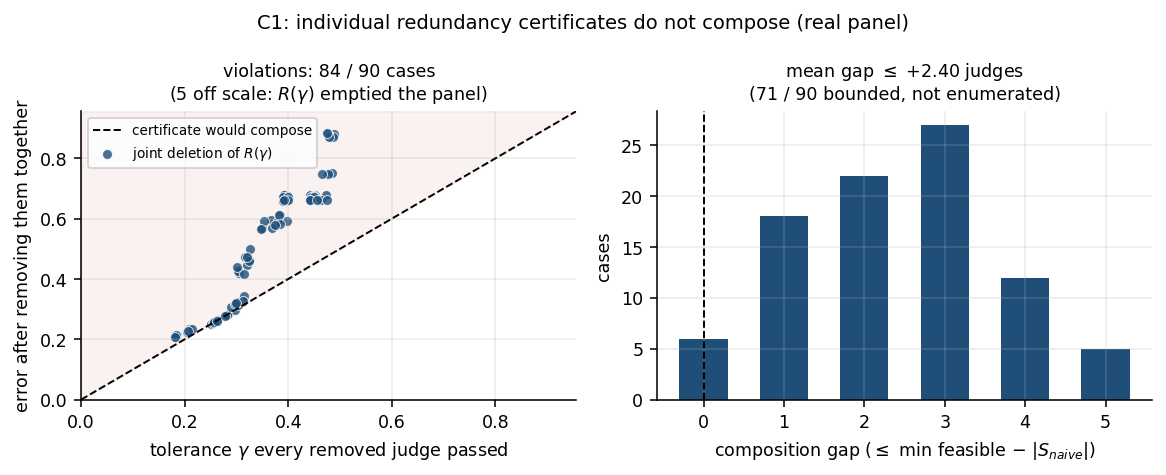

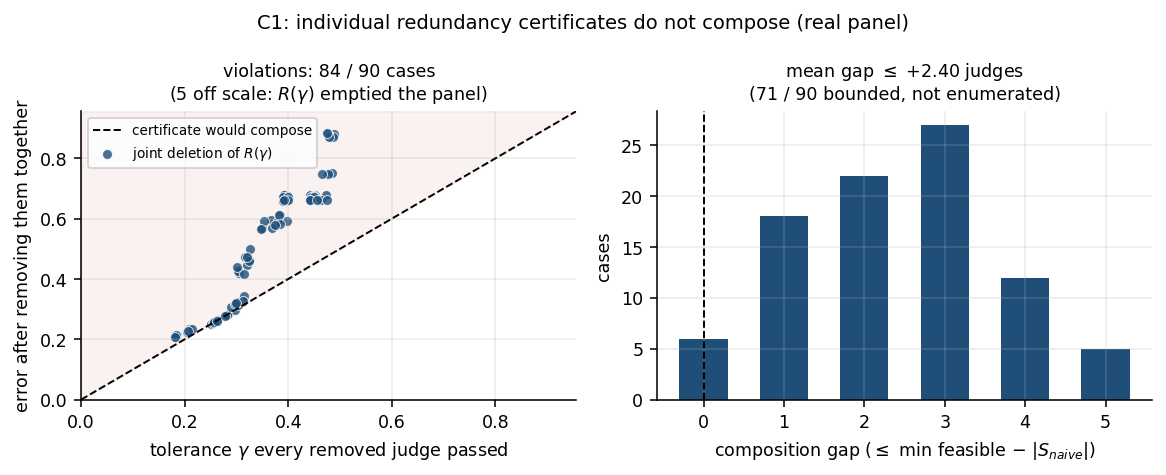

In [5]:
display(F.fig_c1_real(PATHS["e0_real"]))

### The same claim where the answer is known in advance

Two controlled constructions. `duplicated_extremes` contains exact duplicates,
so each copy is individually redundant but the pair is not. `curved_arc_9`
places judges on a curve where every judge is nearly interpolated by its
neighbours.

,instance,gamma,removable,naive_size,naive_coverage,min_feasible,min_feasible_exact,min_feasible_floor,composition_gap,cycles,seeds,naive_set_fails
0,curved_arc_9,0.0020,0.0000,9.0000,0.0000,9.0000,True,9.0000,0.0000,1.0000,5,False
1,curved_arc_9,0.0050,7.0000,2.0000,0.0551,5.0000,True,5.0000,3.0000,1.0000,5,True
2,curved_arc_9,0.0100,7.0000,2.0000,0.0551,4.0000,True,4.0000,2.0000,1.0000,5,True
3,curved_arc_9,0.0200,7.0000,2.0000,0.0551,3.0000,True,3.0000,1.0000,1.0000,5,True
4,curved_arc_9,0.0400,9.0000,0.0000,inf,2.0000,True,2.0000,2.0000,1.0000,5,True
5,curved_arc_9,0.0800,9.0000,0.0000,inf,2.0000,True,2.0000,2.0000,1.0000,5,True
6,duplicated_extremes,0.0020,6.0000,0.0000,inf,3.0000,True,3.0000,3.0000,3.0000,5,True
7,duplicated_extremes,0.0050,6.0000,0.0000,inf,3.0000,True,3.0000,3.0000,3.0000,5,True
8,duplicated_extremes,0.0100,6.0000,0.0000,inf,3.0000,True,3.0000,3.0000,3.0000,5,True
9,duplicated_extremes,0.0200,6.0000,0.0000,inf,3.0000,True,3.0000,3.0000,3.0000,5,True


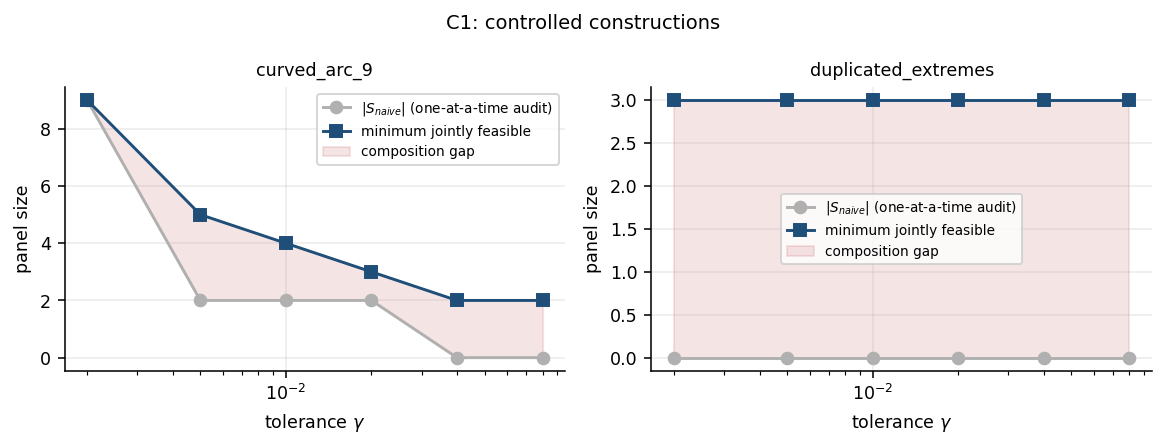

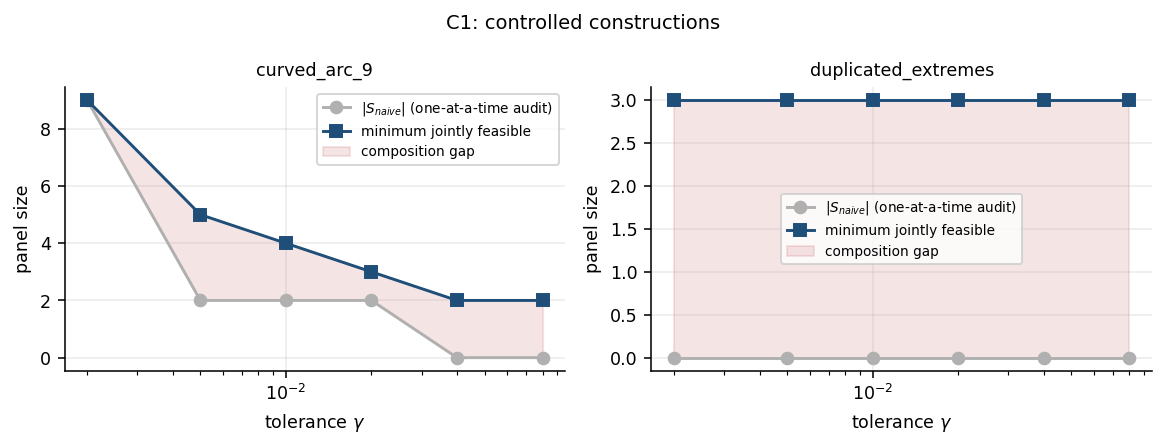

In [6]:
syn = R.c1_headline(PATHS["e0_synthetic"], gamma_source=None)
display(syn)
display(F.fig_c1_synthetic(PATHS["e0_synthetic"]))

---

## Claim C2 — the physical-to-virtual compression frontier

> A small physical panel reconstructs every virtual judge to within a small
> worst-context error on held-out items.

**How it is tested.** For each budget $k$, pick a physical subset $S$, fit one
simplex weight vector $w^{(j)}$ per judge on FIT, and score those weights on the
locked TEST split. Weights are never fitted on the split they are scored on.

The headline is the **worst** judge in its **worst** context, not the average —
C2 is a statement about every judge being preserved.

In [7]:
c2 = R.c2_table(PATHS["e1"], "TEST")
cov = c2[c2["method"] == "coverage_backward"].sort_values("k")
display(cov[["k", "worst_judge_tv", "mean_judge_tv", "median_item_tv",
             "p95_item_tv", "verdict_agreement", "calls_avoided_frac"]])

,k,worst_judge_tv,mean_judge_tv,median_item_tv,p95_item_tv,verdict_agreement,calls_avoided_frac
0,1,0.7884,0.6254,0.5467,0.9962,0.4448,0.9474
1,2,0.6747,0.5012,0.4349,0.9650,0.4824,0.8947
2,3,0.6238,0.3543,0.2738,0.8646,0.6630,0.8421
3,4,0.5251,0.2987,0.2166,0.7912,0.7229,0.7895
4,5,0.5127,0.2616,0.1974,0.7110,0.7526,0.7368
5,6,0.4513,0.2304,0.1503,0.6729,0.7819,0.6842
6,7,0.4204,0.1998,0.1058,0.6188,0.8146,0.6316
7,8,0.3898,0.1758,0.0696,0.5820,0.8409,0.5789
8,9,0.3588,0.1527,0.0202,0.5391,0.8626,0.5263
9,10,0.3478,0.1331,0.0000,0.5021,0.8786,0.4737


In [8]:
half = cov[cov["k"] <= max(1, int(cov["k"].max()) // 2)].iloc[-1]
print(f"at k = {int(half['k'])} of {int(cov['k'].max())} judges "
      f"({half['calls_avoided_frac']:.0%} of judge calls avoided):")
print(f"  median item TV        {half['median_item_tv']:.4f}")
print(f"  95th percentile TV    {half['p95_item_tv']:.4f}")
print(f"  verdict agreement     {half['verdict_agreement']:.1%}")
print(f"  worst judge, worst ctx {half['worst_judge_tv']:.4f}   <- what C2 is stated over")
print()
print("The typical item compresses well. The worst-judge worst-context error is")
print("the number the claim is about, and it is reported as measured.")

at k = 9 of 19 judges (53% of judge calls avoided):
  median item TV        0.0202
  95th percentile TV    0.5391
  verdict agreement     86.3%
  worst judge, worst ctx 0.3588   <- what C2 is stated over

The typical item compresses well. The worst-judge worst-context error is
the number the claim is about, and it is reported as measured.


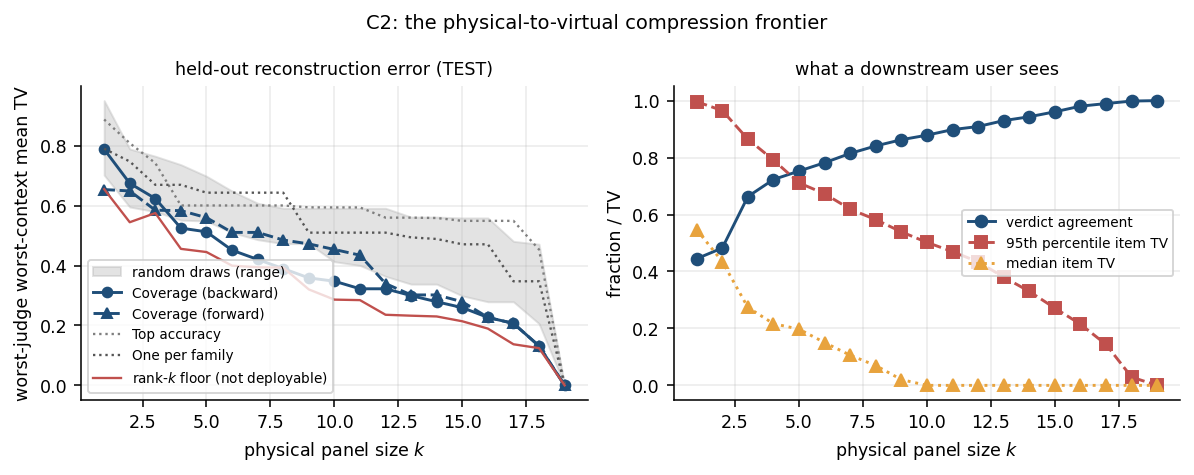

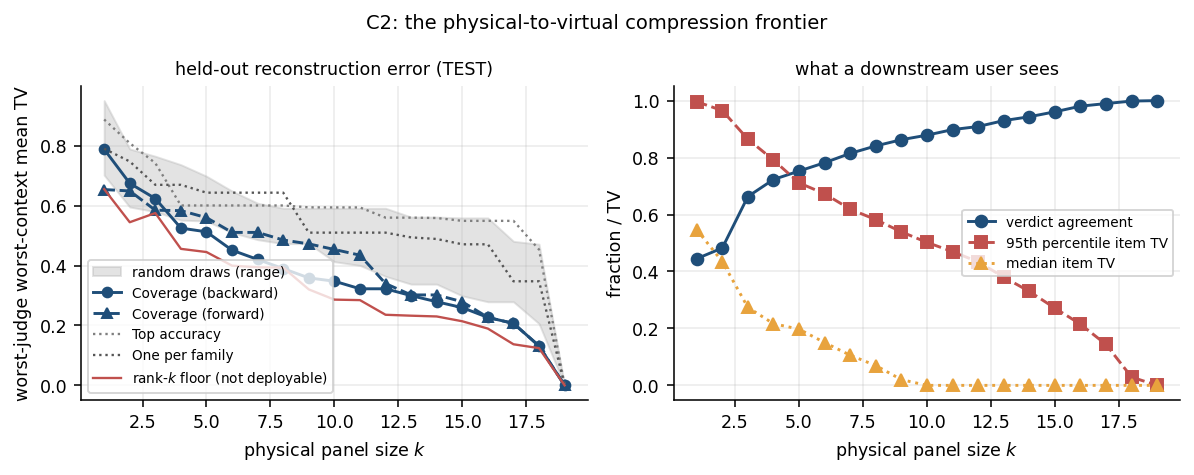

In [9]:
display(F.fig_c2_frontier(PATHS["e1"], PATHS["c3"]))

---

## Claim C3 — coverage-based selection beats the baselines

> Choosing the physical panel by the coverage functional does better than
> accuracy ranking, random choice, family diversity, cost heuristics, and
> standard pairwise-geometry selection.

**How it is tested.** Equal panel size $k$ for every method, averaged over the
non-trivial budgets and over all split seeds, with an item cluster bootstrap.
Trivial budgets are excluded: at $k = 1$ no convex combination exists, and at
$k = N$ every judge reconstructs itself exactly for every method, so no method
can differ there.

In [10]:
head = R.c3_headline(PATHS["c3"])
print(f"averaged over k in {head['k_values'].iloc[0]} and "
      f"{len(payload['split_seeds'])} split seeds, {payload['n_bootstrap']} bootstrap replicates")
print()
display(head[["label", "worst_judge_tv", "boot_lo", "boot_hi",
              "mean_judge_tv", "verdict_agreement", "p95_item_tv"]])

averaged over k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18] and 5 split seeds, 2000 bootstrap replicates



,label,worst_judge_tv,boot_lo,boot_hi,mean_judge_tv,verdict_agreement,p95_item_tv
0,Coverage (backward),0.3750,0.3640,0.3913,0.1645,0.8442,0.5052
1,Coverage (forward),0.4110,0.4004,0.4290,0.1779,0.8205,0.5779
2,Top accuracy,0.5844,0.5685,0.6066,0.2204,0.7773,0.7229
3,Random,0.5309,0.5174,0.5508,0.1936,0.8160,0.6341
4,One per family,0.5517,0.5400,0.5694,0.2027,0.8152,0.6418
5,Cheapest first,0.4734,0.4614,0.4919,0.1901,0.8168,0.6034
6,Largest first,0.5559,0.5423,0.5774,0.1969,0.8063,0.6801
7,Correlation clustering,0.4604,0.4477,0.4799,0.1717,0.8544,0.5512
8,k-medoids,0.4710,0.4580,0.4891,0.1737,0.8491,0.5618
9,Hierarchical,0.4642,0.4525,0.4819,0.1764,0.8572,0.5269


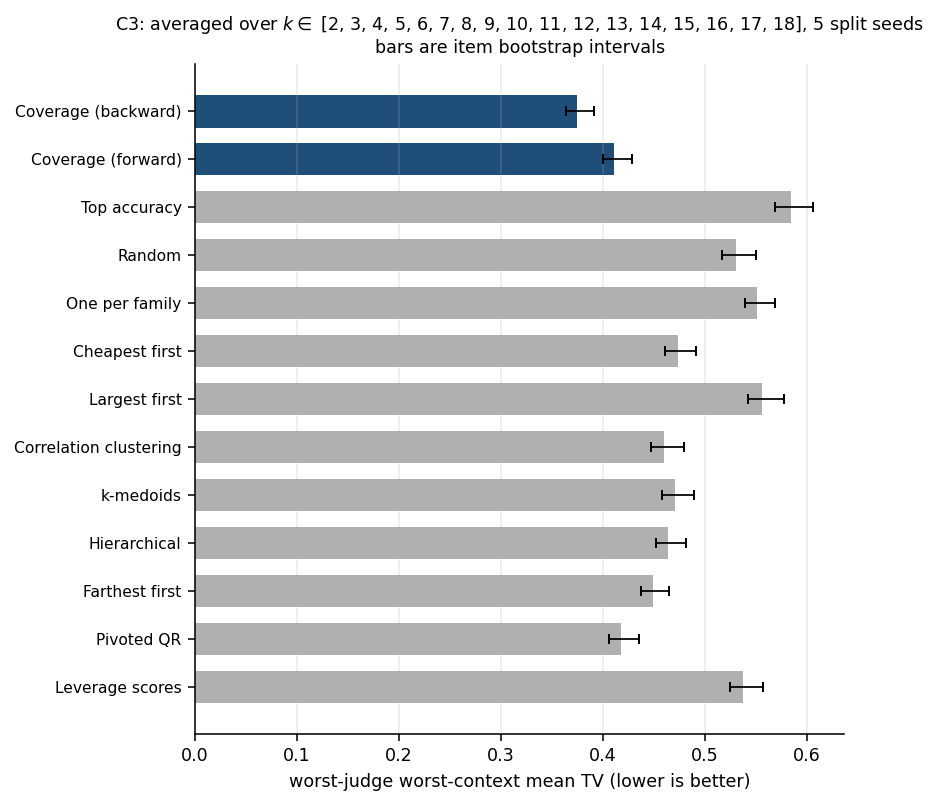

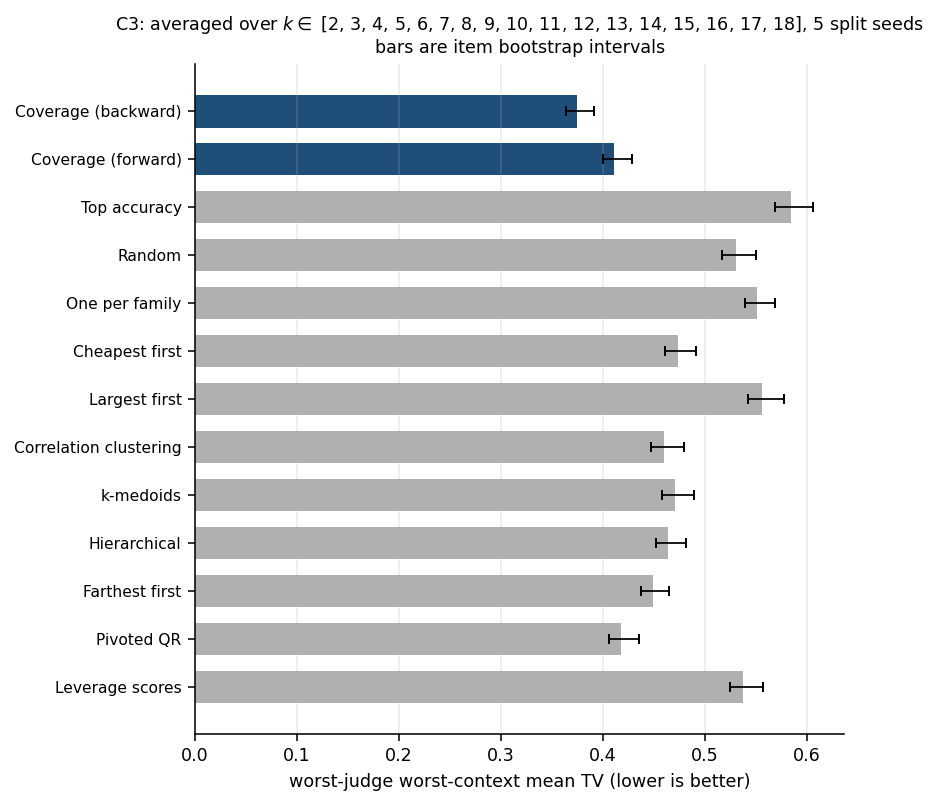

In [11]:
display(F.fig_c3_headline(PATHS["c3"]))

### The bars above overlap. That is the wrong test.

Each bar was computed on its own bootstrap. But every method is scored on the
*same* items, so most of the sampling noise is shared, and asking whether two
independent intervals overlap throws that shared noise away.

Plan section 34.2 asks for the paired version: resample the same items for both
methods and take the difference. Negative means coverage wins. `significant`
counts the (split seed, panel size) cells whose whole interval excludes zero.

,label,delta,lo,hi,significant,cells
11,Top accuracy,-0.2101,-0.2340,-0.1863,85,85
2,Largest first,-0.1819,-0.2044,-0.1604,83,85
8,One per family,-0.1773,-0.1963,-0.1582,85,85
7,Leverage scores,-0.1636,-0.1845,-0.1428,81,85
1,Cheapest first,-0.0990,-0.1184,-0.0798,83,85
6,k-medoids,-0.0960,-0.1149,-0.0771,80,85
5,Hierarchical,-0.0895,-0.1083,-0.0707,78,85
0,Correlation clustering,-0.0861,-0.1060,-0.0664,81,85
4,Farthest first,-0.0737,-0.0913,-0.0565,71,85
9,Pivoted QR,-0.0432,-0.0587,-0.0279,55,85


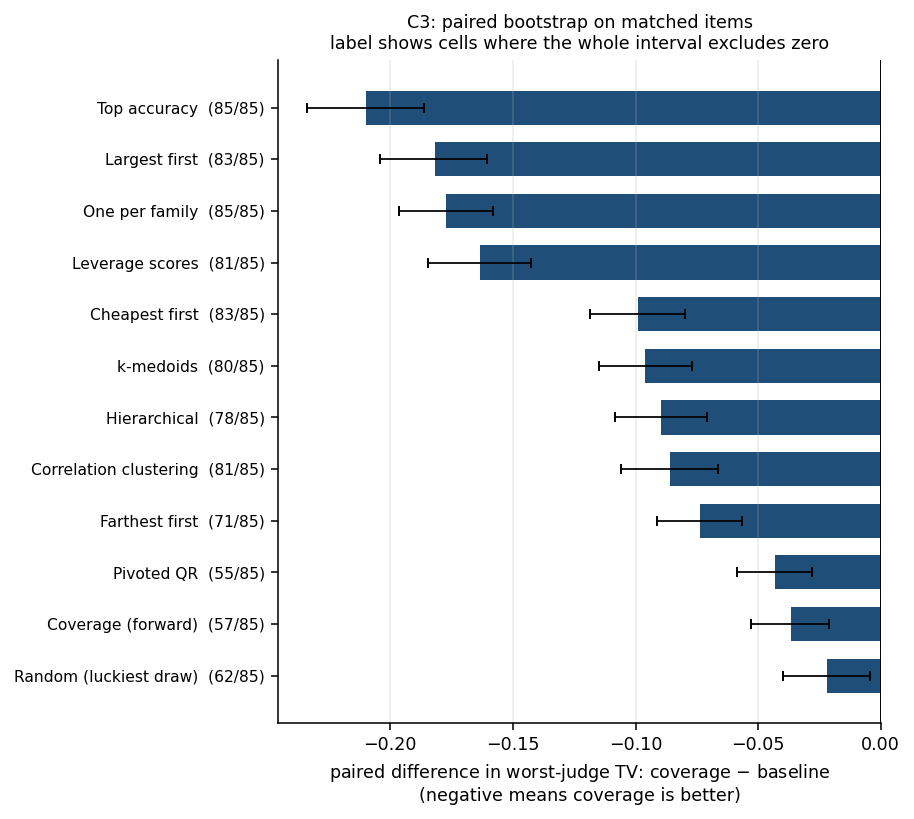

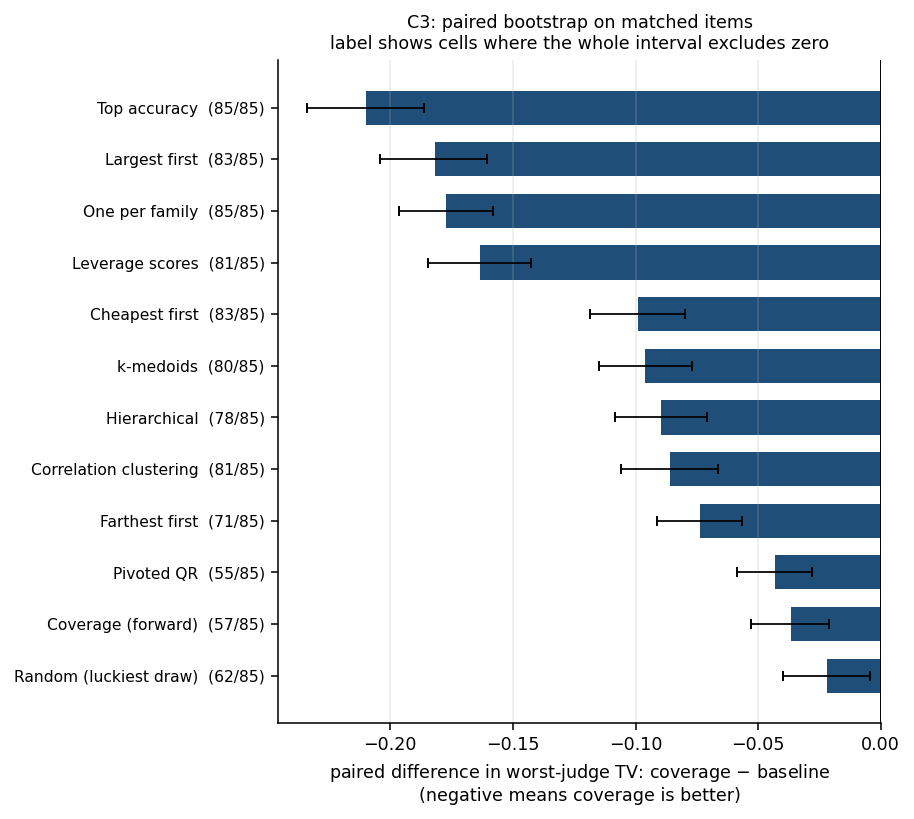

In [12]:
paired = R.c3_paired_table(PATHS["c3"])
pooled = (paired.groupby(["method", "label"], as_index=False)
          .agg(delta=("delta", "mean"), lo=("lo", "mean"), hi=("hi", "mean"),
               significant=("n_seeds_significant", "sum"), cells=("n_seeds", "sum"))
          .sort_values("delta"))
display(pooled[["label", "delta", "lo", "hi", "significant", "cells"]])
display(F.fig_c3_paired(PATHS["c3"]))

In [13]:
total = int(pooled["cells"].iloc[0])
decided = pooled[(pooled["significant"] >= 0.5 * total)
                 & (pooled["method"] != "random_best_draw")]
ties = pooled[(pooled["significant"] <= 0.2 * total)
              & (~pooled["method"].isin(R.COVERAGE_METHODS))
              & (pooled["method"] != "random_best_draw")]

print("coverage wins on a majority of cells against:")
for _, row in decided.iterrows():
    print(f"  {row['label']:<24} {row['delta']:+.3f}   {int(row['significant'])}/{total}")
print()

n_judges = len(block["judges"])
if len(ties):
    print("not separated from coverage on this panel:")
    for _, row in ties.iterrows():
        print(f"  {row['label']:<24} {row['delta']:+.3f}   {int(row['significant'])}/{total}")
    print()
    print(f"Those are pairwise-geometry selectors. At N={n_judges} they often pick the")
    print("identical subset, so there is nothing for the test to resolve.")
else:
    print(f"No baseline is left undecided at N={n_judges}: coverage separates from")
    print("every one of them, including the pairwise-geometry selectors that")
    print("Core-8 could not resolve.")

coverage wins on a majority of cells against:
  Top accuracy             -0.210   85/85
  Largest first            -0.182   83/85
  One per family           -0.177   85/85
  Leverage scores          -0.164   81/85
  Cheapest first           -0.099   83/85
  k-medoids                -0.096   80/85
  Hierarchical             -0.090   78/85
  Correlation clustering   -0.086   81/85
  Farthest first           -0.074   71/85
  Pivoted QR               -0.043   55/85
  Coverage (forward)       -0.037   57/85

No baseline is left undecided at N=19: coverage separates from
every one of them, including the pairwise-geometry selectors that
Core-8 could not resolve.


### Does any of this depend on which split we drew?

Plan section 34.4: mean, SD, min and max across the five predeclared split
seeds. A headline that rests on one favourable partition is not a result.

,label,mean,sd,min,max,range,n_seeds
0,Coverage (backward),0.3750,0.0013,0.3736,0.3764,0.0028,5
1,Coverage (forward),0.4110,0.0096,0.3990,0.4222,0.0232,5
2,Top accuracy,0.5844,0.0090,0.5720,0.5951,0.0232,5
3,Random,0.5309,0.0020,0.5280,0.5333,0.0053,5
4,One per family,0.5517,0.0051,0.5450,0.5577,0.0126,5
5,Cheapest first,0.4734,0.0022,0.4715,0.4770,0.0055,5
6,Largest first,0.5559,0.0078,0.5511,0.5698,0.0187,5
7,Correlation clustering,0.4604,0.0063,0.4550,0.4702,0.0152,5
8,k-medoids,0.4710,0.0026,0.4669,0.4734,0.0065,5
9,Hierarchical,0.4642,0.0018,0.4617,0.4661,0.0044,5


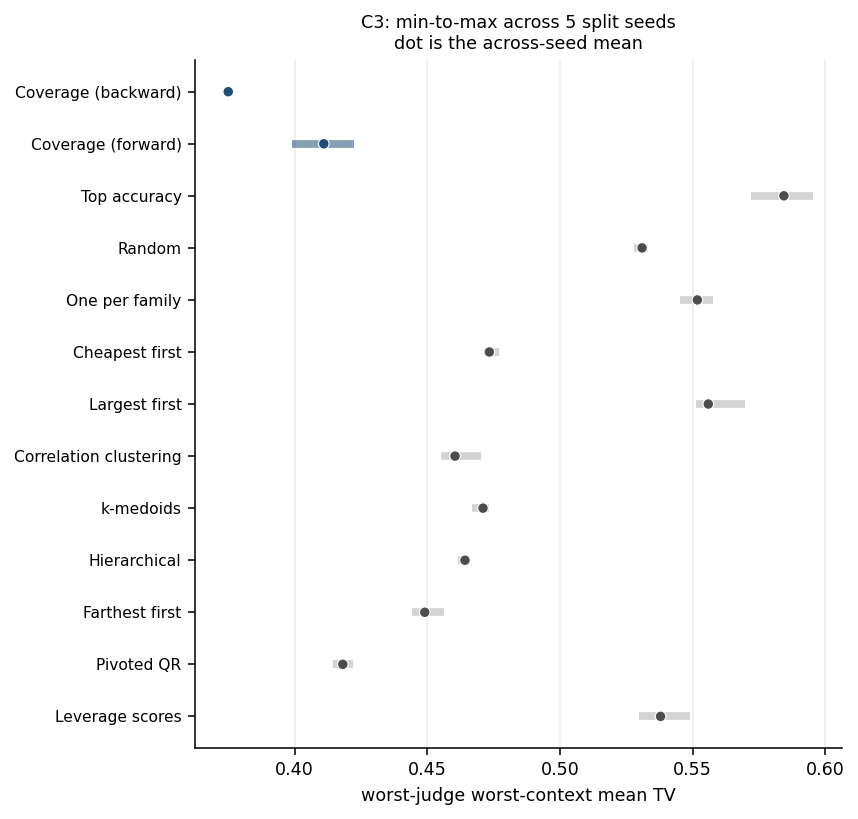

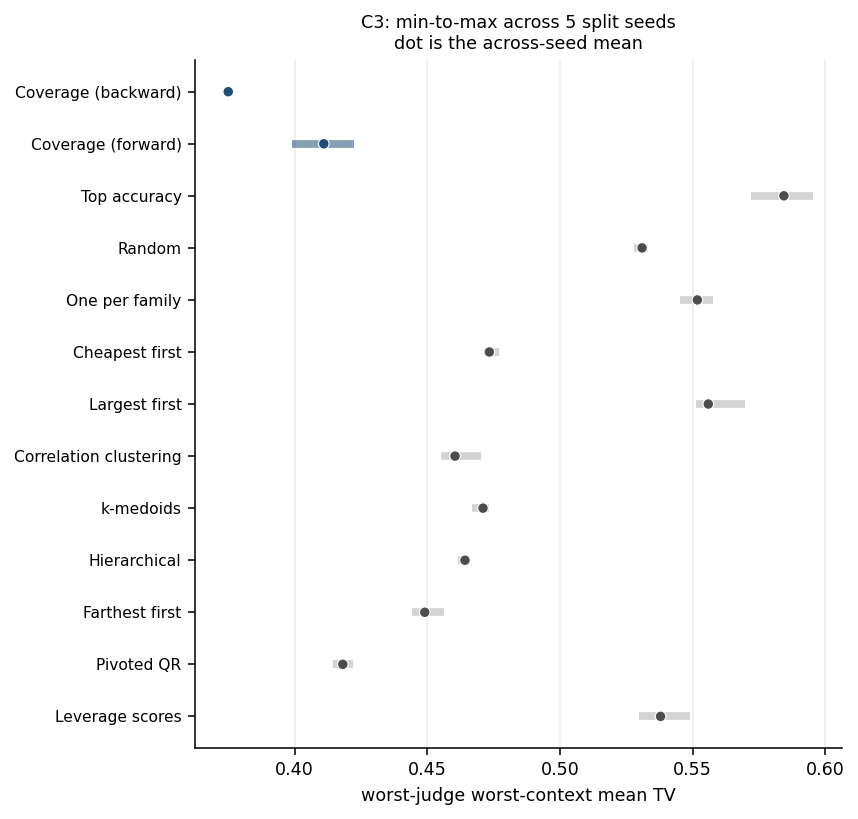

In [14]:
rob = R.c3_split_robustness(PATHS["c3"])
display(rob[["label", "mean", "sd", "min", "max", "range", "n_seeds"]])
display(F.fig_c3_split_robustness(PATHS["c3"]))

### Cost

Judges are not equally expensive, so equal-$k$ is not equal-cost. These are
measured inference seconds on the scored items, not a parameter-count proxy.

,k,worst_judge_tv,verdict_agreement,calls_avoided_frac,panel_seconds,seconds_saved,speedup
0,1,0.7884,0.4355,0.9474,1578.7308,34701.9336,22.9809
1,2,0.6719,0.4763,0.8947,2519.4881,33761.1763,14.4000
2,3,0.6088,0.6584,0.8421,5028.7684,31251.8960,7.2146
3,4,0.5333,0.7186,0.7895,7002.2641,29278.4003,5.1813
4,5,0.5100,0.7494,0.7368,8357.2004,27923.4640,4.3412
5,6,0.4545,0.7761,0.6842,10013.9856,26266.6787,3.6230
6,7,0.4123,0.8108,0.6316,11702.9855,24577.6789,3.1001
7,8,0.3975,0.8363,0.5789,12600.3259,23680.3385,2.8793
8,9,0.3615,0.8580,0.5263,15761.8228,20518.8415,2.3018
9,10,0.3485,0.8747,0.4737,18622.4951,17658.1692,1.9482


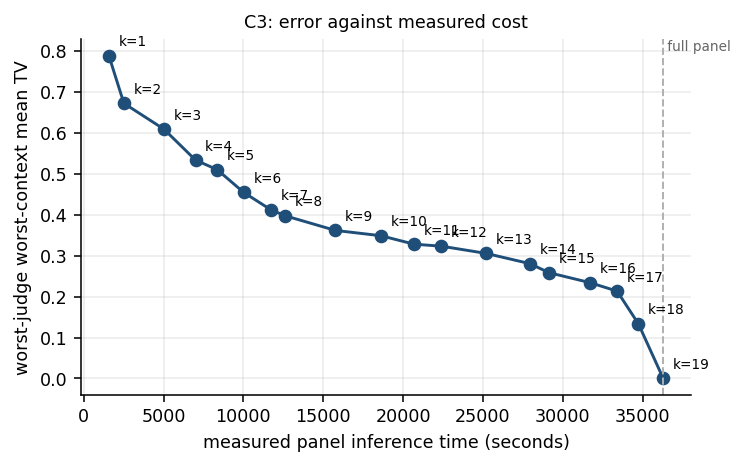

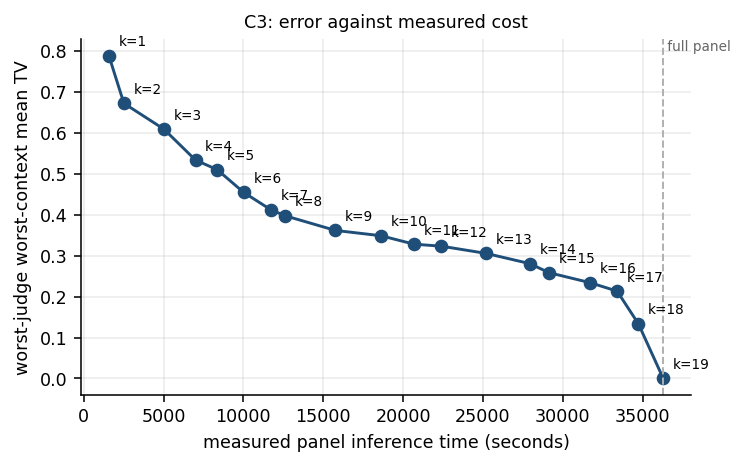

In [15]:
display(R.c3_cost_table(PATHS["c3"]))
display(F.fig_c3_cost(PATHS["c3"]))

### How much of the remaining error is unavoidable

The rank-$k$ floor is what a best-case $k$-dimensional basis achieves. It is
**not deployable** — its basis vectors are not real judges, so there is nothing
to run to produce them — but it bounds what any choice of $k$ judges could hope
for. The distance between the coverage curve and this floor is the part of the
error that is due to being restricted to real judges.

In [16]:
display(R.lowrank_floor_table(PATHS["c3"]))

,method,k,worst_judge_tv,mean_judge_tv,label
0,nmf,1,0.6036,0.4322,NMF floor (not deployable)
1,nmf,2,0.5607,0.3882,NMF floor (not deployable)
2,nmf,3,0.5813,0.3626,NMF floor (not deployable)
3,nmf,4,0.5358,0.3351,NMF floor (not deployable)
4,nmf,5,0.4806,0.3045,NMF floor (not deployable)
5,nmf,6,0.4198,0.2735,NMF floor (not deployable)
6,nmf,7,0.3937,0.2466,NMF floor (not deployable)
7,nmf,8,0.3870,0.2252,NMF floor (not deployable)
8,nmf,9,0.3773,0.1983,NMF floor (not deployable)
9,nmf,10,0.3777,0.1776,NMF floor (not deployable)


### The reconstruction rule matters as much as the subset

Same selected judges, five fitting rules. Unconstrained rules can score lower on
TV while leaving the simplex — their output is then not a probability
distribution and cannot be shipped as a judge verdict. `off_simplex_frac` is the
price they pay, and it is why the simplex rule is the primary one.

rule,nearest,nonneg,ridge,simplex,uniform
k,,,,,
1,0.7884,0.5850,0.5841,0.7884,0.7884
2,0.7637,0.6284,0.6277,0.6747,0.7700
3,0.7637,0.6097,0.6086,0.6238,0.7083
4,0.6972,0.6097,0.5982,0.5251,0.6123
5,0.6922,0.5363,0.5422,0.5127,0.6212
6,0.6123,0.5026,0.4764,0.4513,0.5815
7,0.6123,0.5013,0.4708,0.4204,0.5900
8,0.6123,0.4900,0.4604,0.3898,0.5949
9,0.5666,0.4900,0.4591,0.3588,0.5899


rule,nearest,nonneg,ridge,simplex,uniform
k,,,,,
1,0.0000,0.9474,0.9474,0.0000,0.0000
2,0.0000,0.8947,0.8947,0.0000,0.0000
3,0.0000,0.8421,0.8421,0.0000,0.0000
4,0.0000,0.7895,0.7895,0.0000,0.0000
5,0.0000,0.7368,0.7368,0.0000,0.0000
6,0.0000,0.6842,0.6842,0.0000,0.0000
7,0.0000,0.6316,0.6316,0.0000,0.0000
8,0.0000,0.5789,0.5789,0.0000,0.0000
9,0.0000,0.5263,0.5263,0.0000,0.0000


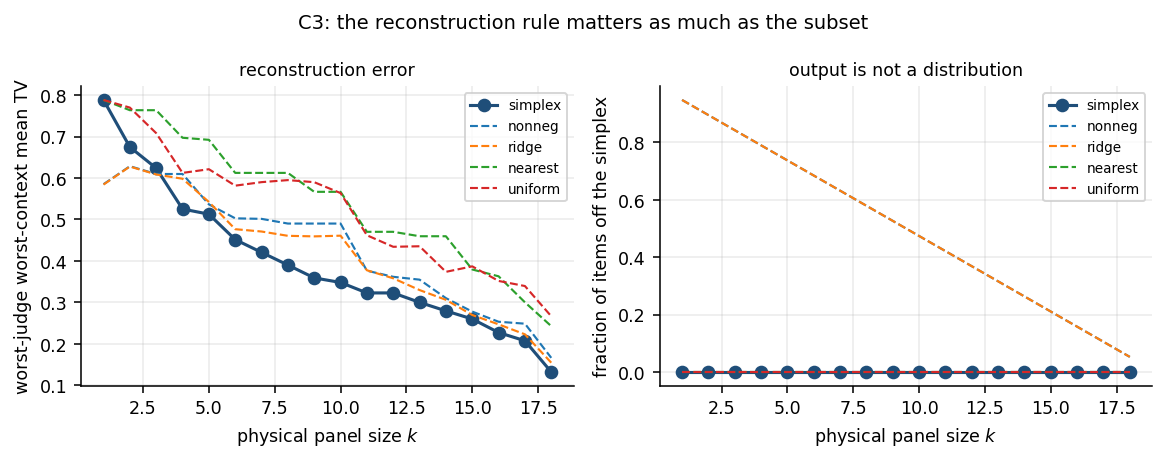

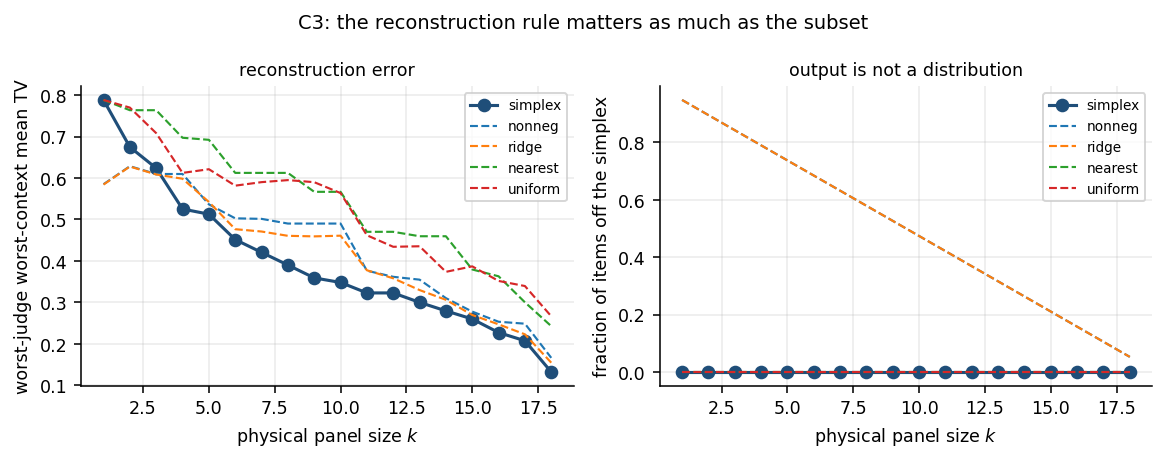

In [17]:
rec = R.reconstruction_table(PATHS["c3"])
display(rec.pivot(index="k", columns="rule", values="worst_judge_tv"))
display(rec.pivot(index="k", columns="rule", values="off_simplex_frac"))
display(F.fig_c3_reconstruction(PATHS["c3"]))

---

## Claim C4 — stress specialists and multi-context selection

> Selecting on clean items alone retires judges that are redundant on average
> but distinctive under position swaps, verbosity changes, rubric changes or a
> hidden reference. Selecting against the worst context retains those stress
> specialists and lowers worst-context error.

**How it is tested.** Exactly one variable moves: which contexts the selector is
allowed to see. Panel, greedy backward selector and locked TEST split are held
fixed, and **all three arms are scored on all seven contexts**, so equal-$k$
comparison is fair.

The two baselines are not interchangeable and must not be pooled:

- `clean_select` is handicapped **only at selection time** and still receives
  worst-context weights. This is the arm that isolates the selection mistake,
  which is what C4 is a claim about.
- `clean_pipeline` is handicapped at selection **and** at fitting. This is what
  someone who never considered contexts would actually deploy.

`delta` is baseline minus robust, so positive is the direction the claim
predicts.

,baseline,k,delta_mean,delta_sd,delta_min,delta_max,n_seeds_better,n_seeds,robust_wins_every_seed
0,clean_pipeline,2,0.1657,0.0184,0.1425,0.1908,5,5,True
1,clean_pipeline,4,0.3163,0.0120,0.3032,0.3297,5,5,True
2,clean_pipeline,6,0.3945,0.0189,0.3735,0.4200,5,5,True
3,clean_pipeline,8,0.4516,0.0187,0.4279,0.4768,5,5,True
4,clean_pipeline,10,0.2540,0.0092,0.2424,0.2625,5,5,True
5,clean_pipeline,12,0.2789,0.0087,0.2669,0.2870,5,5,True
6,clean_pipeline,14,0.3214,0.0072,0.3103,0.3280,5,5,True
7,clean_pipeline,16,0.3527,0.0060,0.3436,0.3579,5,5,True
8,clean_pipeline,18,0.1981,0.0057,0.1888,0.2030,5,5,True
9,clean_select,2,0.0088,0.0197,0.0000,0.0440,1,5,False


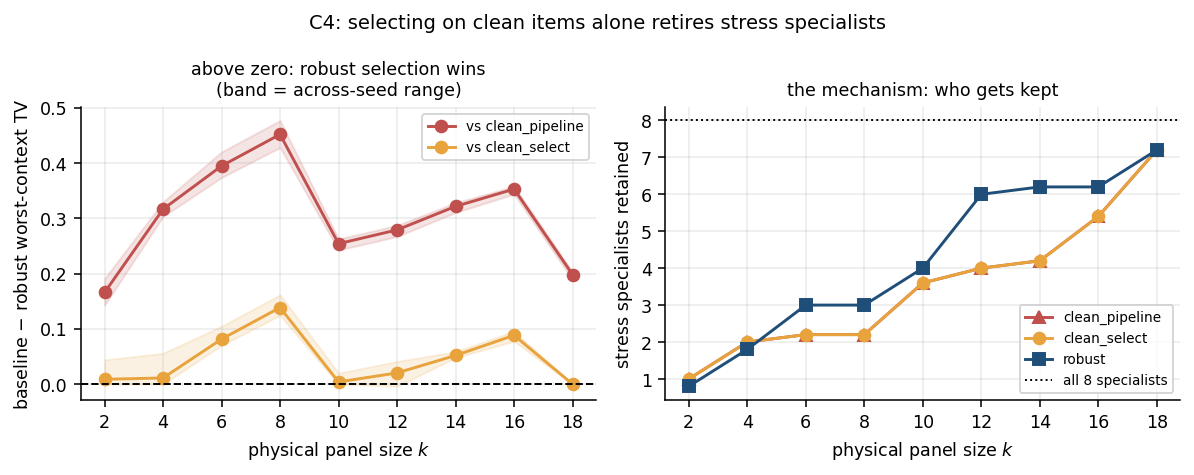

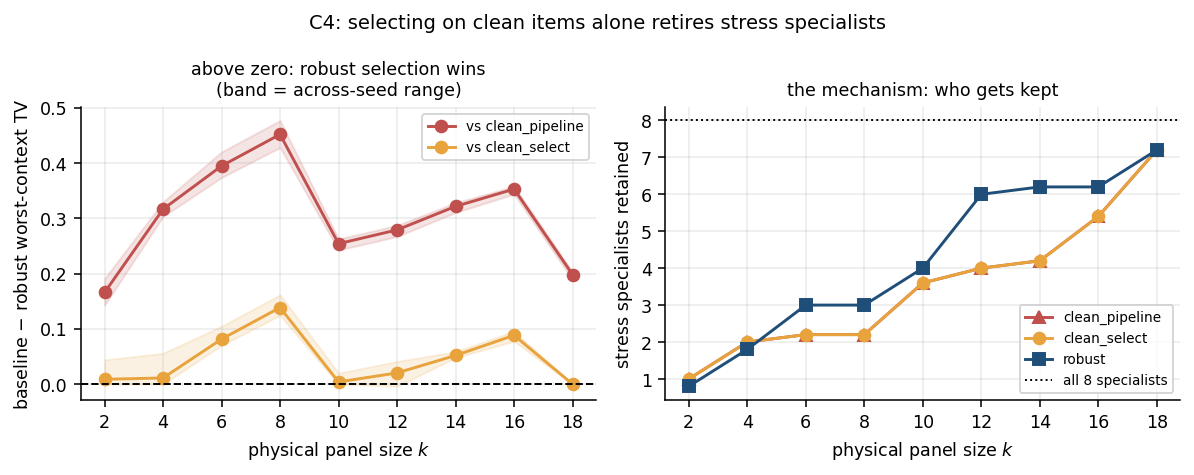

In [18]:
c4 = R.c4_headline(PATHS["c4"])
display(c4[["baseline", "k", "delta_mean", "delta_sd", "delta_min", "delta_max",
            "n_seeds_better", "n_seeds", "robust_wins_every_seed"]])
display(F.fig_c4_stress(PATHS["c4"]))

In [19]:
# The two arms are scored separately and never averaged together.  Pooling them
# would let the pipeline arm's easy win -- it is handicapped at fitting as well as
# selection -- stand in as evidence for a claim that is only about selection.
for baseline in ["clean_pipeline", "clean_select"]:
    arm = c4[c4["baseline"] == baseline]
    if not len(arm):
        continue
    print(f"{baseline}")
    print(f"  mean delta over budgets     {arm['delta_mean'].mean():+.3f} TV")
    print(f"  unanimous across seeds at   {int(arm['robust_wins_every_seed'].sum())}"
          f" of {len(arm)} budgets")
    print(f"  worst single (seed, budget)  {arm['delta_min'].min():+.3f}")
    print()

pipe = c4[c4["baseline"] == "clean_pipeline"]["delta_mean"].mean()
sel = c4[c4["baseline"] == "clean_select"]["delta_mean"].mean()
print(f"selection alone accounts for {sel / pipe:.0%} of the total effect;")
print("the rest is which contexts the weights were fitted on.")

clean_pipeline
  mean delta over budgets     +0.304 TV
  unanimous across seeds at   9 of 9 budgets
  worst single (seed, budget)  +0.142

clean_select
  mean delta over budgets     +0.045 TV
  unanimous across seeds at   4 of 9 budgets
  worst single (seed, budget)  -0.004

selection alone accounts for 15% of the total effect;
the rest is which contexts the weights were fitted on.


### Which judges are the stress specialists

A judge flagged under a single partition is a candidate, not a finding, so
`in_every_seed` is the column to read. `binding_contexts` is the context that
made the judge distinctive — if a judge is only ever bound by the same one or two
contexts, that says which stressor the panel is actually sensitive to.

In [20]:
spec = R.c4_specialists(PATHS["c4"])
display(spec)

stable = spec[spec["in_every_seed"]]
print(f"{len(stable)} of {len(spec)} flagged judges are flagged under every split seed: "
      f"{', '.join(stable['judge']) if len(stable) else 'none'}")
ctx = sorted({c for row in stable["binding_contexts"] for c in row.split(",") if c})
print(f"binding contexts across those judges: {', '.join(ctx) if ctx else 'none'}")

,judge,n_seeds_flagged,in_every_seed,binding_contexts
0,J02,5,True,"I2_correctness_rubric,I3_bias_resistant_rubric"
1,J05,5,True,I3_bias_resistant_rubric
2,J06,5,True,"I2_correctness_rubric,I3_bias_resistant_rubric"
3,J09,4,False,
4,J10,5,True,I3_bias_resistant_rubric
5,J12,1,False,
6,J15,5,True,I3_bias_resistant_rubric
7,J19,1,False,
8,J20,5,True,I3_bias_resistant_rubric


6 of 9 flagged judges are flagged under every split seed: J02, J05, J06, J10, J15, J20
binding contexts across those judges: I2_correctness_rubric, I3_bias_resistant_rubric


---

## Build the delivery package

Writes `results/export/<panel>/` with `tables/`, `figures/`, `raw/`,
`SUMMARY.md` and a `manifest.json` carrying a SHA-256 per file plus the git
commit, then zips it.

Everything in that zip came from the same `report.py` and `figures.py` calls
used above, so the package cannot disagree with this notebook.

In [21]:
from experiments.export_results import export

zip_path = export(PANEL)
print()
print("send this file:", zip_path)

tables:  17


figures: 9


notebooks: 4



wrote /Users/lucijajurkovic/Desktop/EPCRC/results/export/epcrc_results_core20_20260914.zip  (6.0 MB)

send this file: /Users/lucijajurkovic/Desktop/EPCRC/results/export/epcrc_results_core20_20260914.zip
